**Problem Statement:**

Churn Analysis - Churn model that predicts if the customer leave or not.

In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.4 MB/s eta 0:00:00


In [3]:
# import all libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

import pickle
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, models

**Load data**

In [4]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [5]:
# see loaded data

df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [6]:
# load all columns as is it

pd.set_option("display.max_column", None)

In [7]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [8]:
# data info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# check all gender values

df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
# convert TotalCharges to numeric datatype
# map gender and Churn as 0 & 1 for No & Yes respectively

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['gender'] = df['gender'].map({'Female':0, "Male":1})
df['Churn'] = df['Churn'].map({"No":0, "Yes":1})

In [12]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
# check for null values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
# drop null values

df.dropna(inplace=True)

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
# columns

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [19]:
# feature selection
# rfe

numerical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

In [20]:
for col in numerical_features:
  if df[col].dtype == 'object':
    df[col] = pd.factorize(df[col])[0]

numerical_features = [f for f in numerical_features if f in df.columns]

In [21]:
X = df[numerical_features]
y = df['Churn']

In [22]:
df[numerical_features].head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,29.85,29.85
1,1,0,1,0,34,1,1,0,1,1,1,0,0,0,1,1,1,56.95,1889.50


In [23]:
# split data

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, stratify=y)

In [24]:
rf = RandomForestClassifier(n_estimators=200)
rfe = RFE(estimator=rf, n_features_to_select=5) #6,7,8
rfe.fit(X_train,y_train) # use train data only

RFE(estimator=RandomForestClassifier(n_estimators=200), n_features_to_select=5)

In [25]:
selected_features = [f for f,sel in zip(numerical_features,rfe.support_) if sel]
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [26]:
# another model - rfe output

rf.fit(X_train,y_train)
importances = pd.DataFrame({
    'feature': numerical_features,
    'importance': rf.feature_importances_
})
importances = importances.sort_values('importance', ascending=False)
importances

,feature,importance
18,TotalCharges,0.188736
17,MonthlyCharges,0.176184
4,tenure,0.158390
14,Contract,0.076035
16,PaymentMethod,0.057540
8,OnlineSecurity,0.047119
11,TechSupport,0.039785
0,gender,0.027208
15,PaperlessBilling,0.024355
10,DeviceProtection,0.024301


<Axes: xlabel='importance', ylabel='feature'>

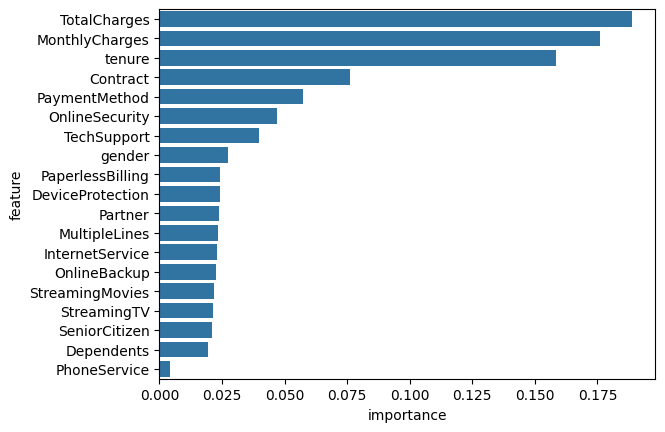

In [27]:
# plot importances feature

sns.barplot(x='importance', y='feature', data=importances)

In [28]:
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

Features output from both selected_features and importances are close.

Will used selected_features output

In [29]:
# model building
# use selected features and split data

X = df[selected_features]
y = df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.20)

In [30]:
# scale data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# save it, scaler

with open('scaler.pkl', 'wb') as f:
  pickle.dump(scaler,f)

In [32]:
# create neural network
#  based on my data what feature? 5 input layer 5 nodes?

def create_model():
  model = models.Sequential([
      layers.Dense(64, activation='relu', input_shape = (5,)),
      layers.Dense(32, activation='relu'),
      layers.Dense(16, activation='relu'),
      layers.Dense(1, activation='sigmoid')
  ])
  model.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy'])
  return model


In [33]:
ann_model = create_model()
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7691 - loss: 0.4851 - val_accuracy: 0.7920 - val_loss: 0.4275
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7847 - loss: 0.4355 - val_accuracy: 0.8071 - val_loss: 0.4119
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7867 - loss: 0.4307 - val_accuracy: 0.7964 - val_loss: 0.4174
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7891 - loss: 0.4278 - val_accuracy: 0.8036 - val_loss: 0.4103
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7873 - loss: 0.4261 - val_accuracy: 0.8089 - val_loss: 0.4062
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7927 - loss: 0.4250 - val_accuracy: 0.8116 - val_loss: 0.4057
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7944 - loss: 0.4235 - val_accuracy: 0.8124 - val_loss: 0.4072
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7967 - loss: 0.4230 - val_accuracy: 0.

Text(0.5, 1.0, 'Training and Validation Loss')

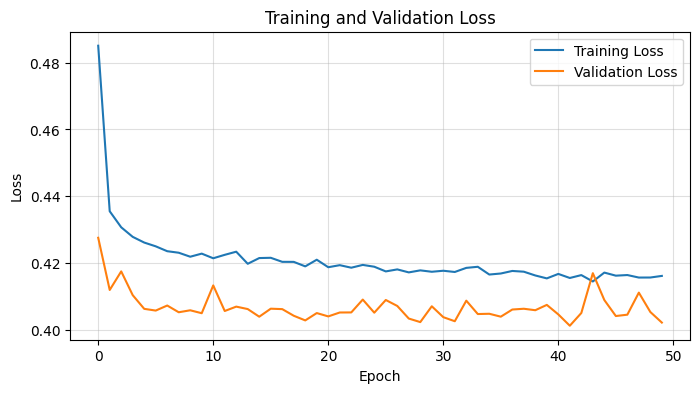

In [35]:
# visualize training loss vs validation loss

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.grid(alpha=0.4)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

Text(0.5, 1.0, 'Training and Validation Accuracy')

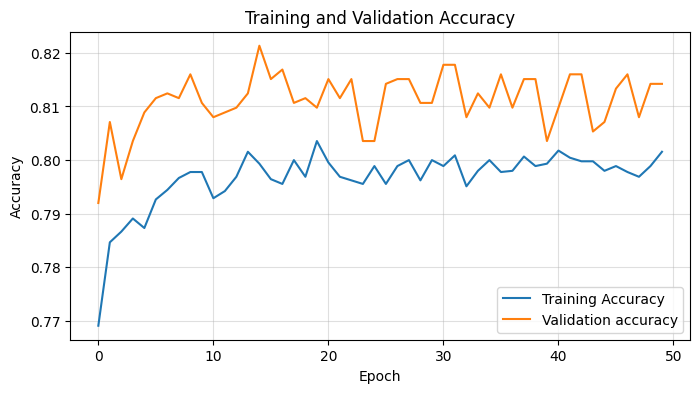

In [36]:
# visualize training and validation accuracy

plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.grid(alpha=0.4)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

In [37]:
# !pip install keras-tuner

In [38]:
# hyperparameter tunning
# number of layers
# number of nodes
# activation function
# regularization - nn do not overfit

# ip - 1,2,3,4 - op
16,32,48, 64, 80, 96,---------256

(16, 32, 48, 64, 80, 96, -256)

In [46]:
def build_model(hp):
  model = models.Sequential()

  n_layers = hp.Int('n_layers', min_value=1,max_value=4, step=1)

  for i in range(n_layers):
    model.add(layers.Dense(
        units = hp.Int(f"units_{i}", min_value=16, max_value=256, step=16),
        activation = hp.Choice(f"activation_{i}", values=['relu','tanh','elu']),
        kernel_regularizer = tf.keras.regularizers.l2(
            hp.Float(f"lr_{i}", min_value=1e-5, max_value=1e-2, sampling='log')
        )
    ))
    model.add(layers.Dropout(
        rate = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)
    ))

  model.add(layers.Dense(1, activation='sigmoid'))

  # learning rate and optimizer
  learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
  optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])

  if optimizer == 'adam':
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  elif optimizer == 'rmsprop':
    opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
  else:
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.9)

  model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
  return model


In [40]:
# grid search, random search

In [47]:
# bayesian optimizer

tuner = kt.BayesianOptimization(
    hypermodel = build_model,
    objective = 'val_accuracy',
    max_trials = 20,
    num_initial_points=5, # random
    seed = 10,
    directory = 'keras_tuner_logs',
    project_name = "mission_ai_sekho"
)

tuner.search_space_summary()

Reloading Tuner from keras_tuner_logs/mission_ai_sekho/tuner0.json
Search space summary
Default search space size: 19
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'elu'], 'ordered': False}
lr_0 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
units_1 (Int)
{'default': None, 'condition

In [48]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [49]:
tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    callbacks=[stop_early]
)

In [50]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [51]:
for i in range(best_hps.get('n_layers')):
  print(f" Layer {i+1} units  : {best_hps.get(f'units_{i}')}")
  print(f" Layer {i+1} activation  : {best_hps.get(f'activation_{i}')}")
  print(f" Layer {i+1} dropout  : {best_hps.get(f'dropout_{i}')}")
  print(f" Layer {i+1} L2  : {best_hps.get(f'lr_{i}')}")
print(f" Optimizer  : {best_hps.get(f'optimizer')}")
print(f" Learning Rate  : {best_hps.get(f'learning_rate')}")

 Layer 1 units  : 192
 Layer 1 activation  : relu
 Layer 1 dropout  : 0.0
 Layer 1 L2  : 4.897859754166225e-05
 Layer 2 units  : 256
 Layer 2 activation  : tanh
 Layer 2 dropout  : 0.2
 Layer 2 L2  : 2.5112243506898652e-05
 Layer 3 units  : 208
 Layer 3 activation  : relu
 Layer 3 dropout  : 0.2
 Layer 3 L2  : 4.9018536283274086e-05
 Optimizer  : rmsprop
 Learning Rate  : 0.005367982189315311


In [52]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split = 0.20,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)],
)


Epoch 1/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7676 - loss: 0.4919 - val_accuracy: 0.7742 - val_loss: 0.4582
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7798 - loss: 0.4596 - val_accuracy: 0.8044 - val_loss: 0.4409
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7853 - loss: 0.4520 - val_accuracy: 0.7947 - val_loss: 0.4333
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7871 - loss: 0.4500 - val_accuracy: 0.7884 - val_loss: 0.4474
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7920 - loss: 0.4453 - val_accuracy: 0.8000 - val_loss: 0.4382
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7827 - loss: 0.4446 - val_accuracy: 0.7929 - val_loss: 0.4284
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7949 - loss: 0.4378 - val_accuracy: 0.8160 - val_loss: 0.4246
Epoch 8/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7951 - loss: 0.4380 - val_a

In [54]:
loss, accuracy = best_model.evaluate(X_test_scaled, y_test)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7868 - loss: 0.4383
loss : 0.4383055567741394
accuracy : 0.7867803573608398


Text(0.5, 1.0, 'Training and Validation Loss')

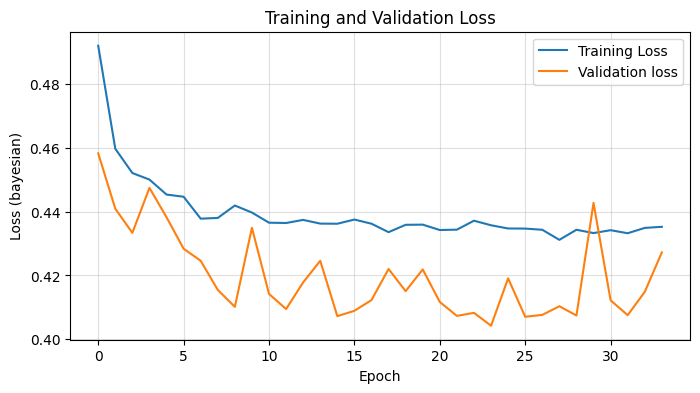

In [55]:
# visualize training loss and validation loss

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.grid(alpha=0.4)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss (bayesian)")
plt.title("Training and Validation Loss")

Text(0.5, 1.0, 'Training and Validation Accuracy')

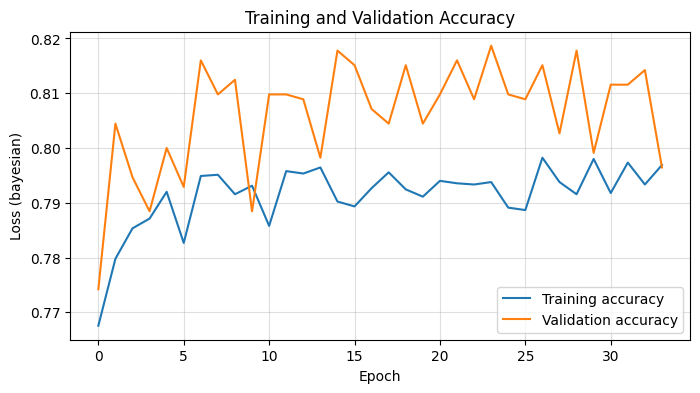

In [56]:
# visualization of training and validation accuracy

plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.grid(alpha=0.4)
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss (bayesian)")
plt.title("Training and Validation Accuracy")

In [57]:
# save my model
# .h5 ? -> .keras

best_model.save("best_churn_model.h5") # weights and bias

In [58]:
with open('selected_feature.pkl','wb') as f:
  pickle.dump(selected_features,f)

In [59]:
# prediction

def load_model_comp():
  model = tf.keras.models.load_model('/content/best_churn_model.h5')

  # load scaler
  with open('scaler.pkl','rb') as f:
    scaler = pickle.load(f)

  with open('selected_feature.pkl','rb') as f:
    selected_features = pickle.load(f)

  return model, scaler, selected_features

In [60]:
X[selected_features].head(3)

,tenure,OnlineSecurity,Contract,MonthlyCharges,TotalCharges
0,1,0,0,29.85,29.85
1,34,1,1,56.95,1889.50
2,2,1,0,53.85,108.15


In [61]:
def pred():
  model, scaler, selected_feature = load_model_comp()

  sample_customer = pd.DataFrame([[34, 1, 0, 56.78, 2300]], columns=selected_features)
  sample_scaled = scaler.transform(sample_customer)
  prediction = model.predict(sample_scaled)[0][0]
  print(f"Churn prob:{prediction}")
  print(f"Will churn :{'yes' if prediction> 0.5 else 'no'}")

pred()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Churn prob:0.22033773362636566
Will churn :no


In [63]:
def pred():
  model, scaler, selected_feature = load_model_comp()

  sample_customer = pd.DataFrame([[1, 0, 0, 29.85, 29.85]], columns=selected_features)
  sample_scaled = scaler.transform(sample_customer)
  prediction = model.predict(sample_scaled)[0][0]
  print(f"Churn prob:{prediction}")
  print(f"Will churn :{'yes' if prediction> 0.5 else 'no'}")

pred()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Churn prob:0.6080366373062134
Will churn :yes
